# Exercícios
## 1) Modificar a profundidade da árvore e comparar resultados
**Objetivo:**

Entender como a profundidade (max_depth) influencia o underfitting e o overfitting.

Altere o parâmetro da árvore de decisão:

model = DecisionTreeClassifier(max_depth=3)

E teste diferentes valores:

max_depth = 1;
max_depth = 5;
max_depth = None (profundidade ilimitada)

Para cada profundidade:

1. Treine o modelo.
2. Plote a árvore de decisão.
3. Gere a fronteira de decisão.
4. Calcule as métricas: accuracy, precisão, recall, F1.

**Pergunta final:** Como a profundidade influencia o overfitting e o desempenho no teste?

## 2) Alterar o dataset e reavaliar o modelo
**Objetivo:**

Explorar como diferentes distribuições de dados afetam o comportamento da árvore.

Modifique o bloco:

X, y = make_classification(...)

Testando diferentes configurações:

1. Aumente o ruído dos rótulos
flip_y=0.15
2. Aumente o número de clusters por classe
n_clusters_per_class=2
3. Aumente o número de features informativas
n_features=4
n_informative=4

Para cada cenário:

1. Refaça o treino.
2. Plote (quando possível).
3. Gere a matriz de confusão.
4. Calcule accuracy, precisão, recall e F1.

**Pergunta final:** Em quais condições o modelo piora mais? Por quê?

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
np.random.seed(42)

### 1.

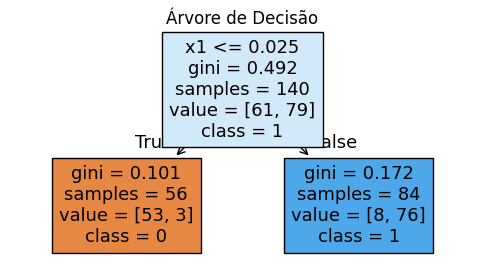

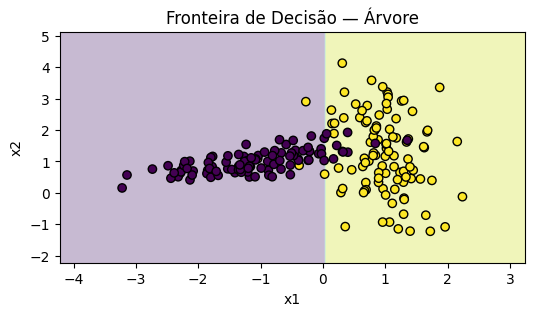

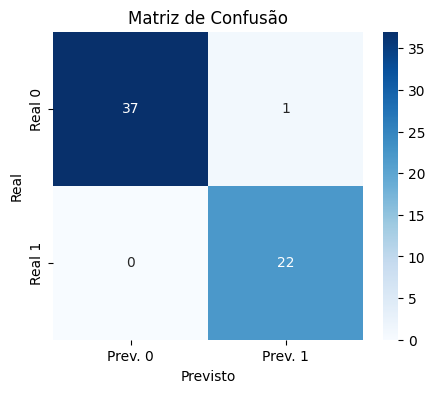

MÉTRICAS DO MODELO
Accuracy : 0.983
Precisão : 0.957
Recall   : 1.000
F1-score : 0.978


In [14]:
#Geração dos dados sintéticos e divisão em treino e teste
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

#MAX_DEPTH = 1
model = DecisionTreeClassifier(max_depth=1)
model.fit(X_train, y_train)

#plotando a árvore de decisão
plt.figure(figsize=(6,3))
plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
plt.title("Árvore de Decisão")
plt.show()

# criando o meshgrid para poder plotar a imagem de superficie
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

#fazendo predições para todos os valores do meshgrd para plotar a fronteira
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plotando a fronteira de decisao
plt.figure(figsize=(6,3))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

plt.title("Fronteira de Decisão — Árvore")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

#plotando a matriz de confusao para identificar verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev. 0", "Prev. 1"],
            yticklabels=["Real 0", "Real 1"])

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# calculando e printando as 4 métricas de avaliação, que ajudam a analisar a matriz de confusão numéricamente
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DO MODELO")
print(f"Accuracy : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

modelo mais simples, gera uma única fronteira de decisão linear. Como a distribuição dos dados não é muito complexa, o desempenho consegue ser satisfatório

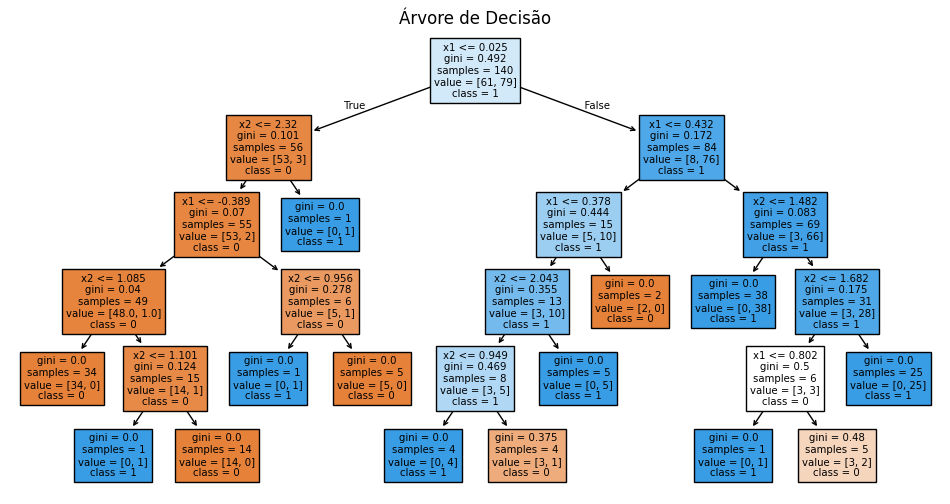

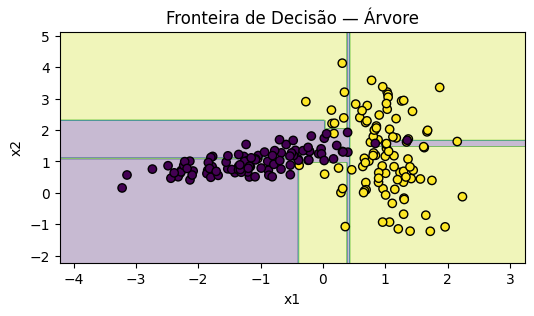

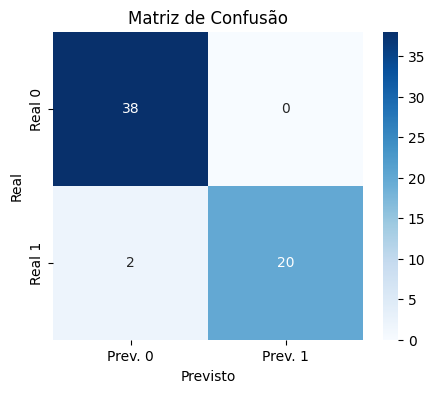

MÉTRICAS DO MODELO
Accuracy : 0.967
Precisão : 1.000
Recall   : 0.909
F1-score : 0.952


In [15]:
#Geração dos dados sintéticos e divisão em treino e teste
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

#MAX_DEPTH = 5
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

#plotando a árvore de decisão
plt.figure(figsize=(12,6))
plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
plt.title("Árvore de Decisão")
plt.show()

# criando o meshgrid para poder plotar a imagem de superficie
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

#fazendo predições para todos os valores do meshgrd para plotar a fronteira
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plotando a fronteira de decisao
plt.figure(figsize=(6,3))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

plt.title("Fronteira de Decisão — Árvore")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

#plotando a matriz de confusao para identificar verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev. 0", "Prev. 1"],
            yticklabels=["Real 0", "Real 1"])

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# calculando e printando as 4 métricas de avaliação, que ajudam a analisar a matriz de confusão numéricamente
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DO MODELO")
print(f"Accuracy : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

As fronteiras de decisão se tornam mais complexas, modelo tenta capturar pontos que estão mais dispersos dos demais

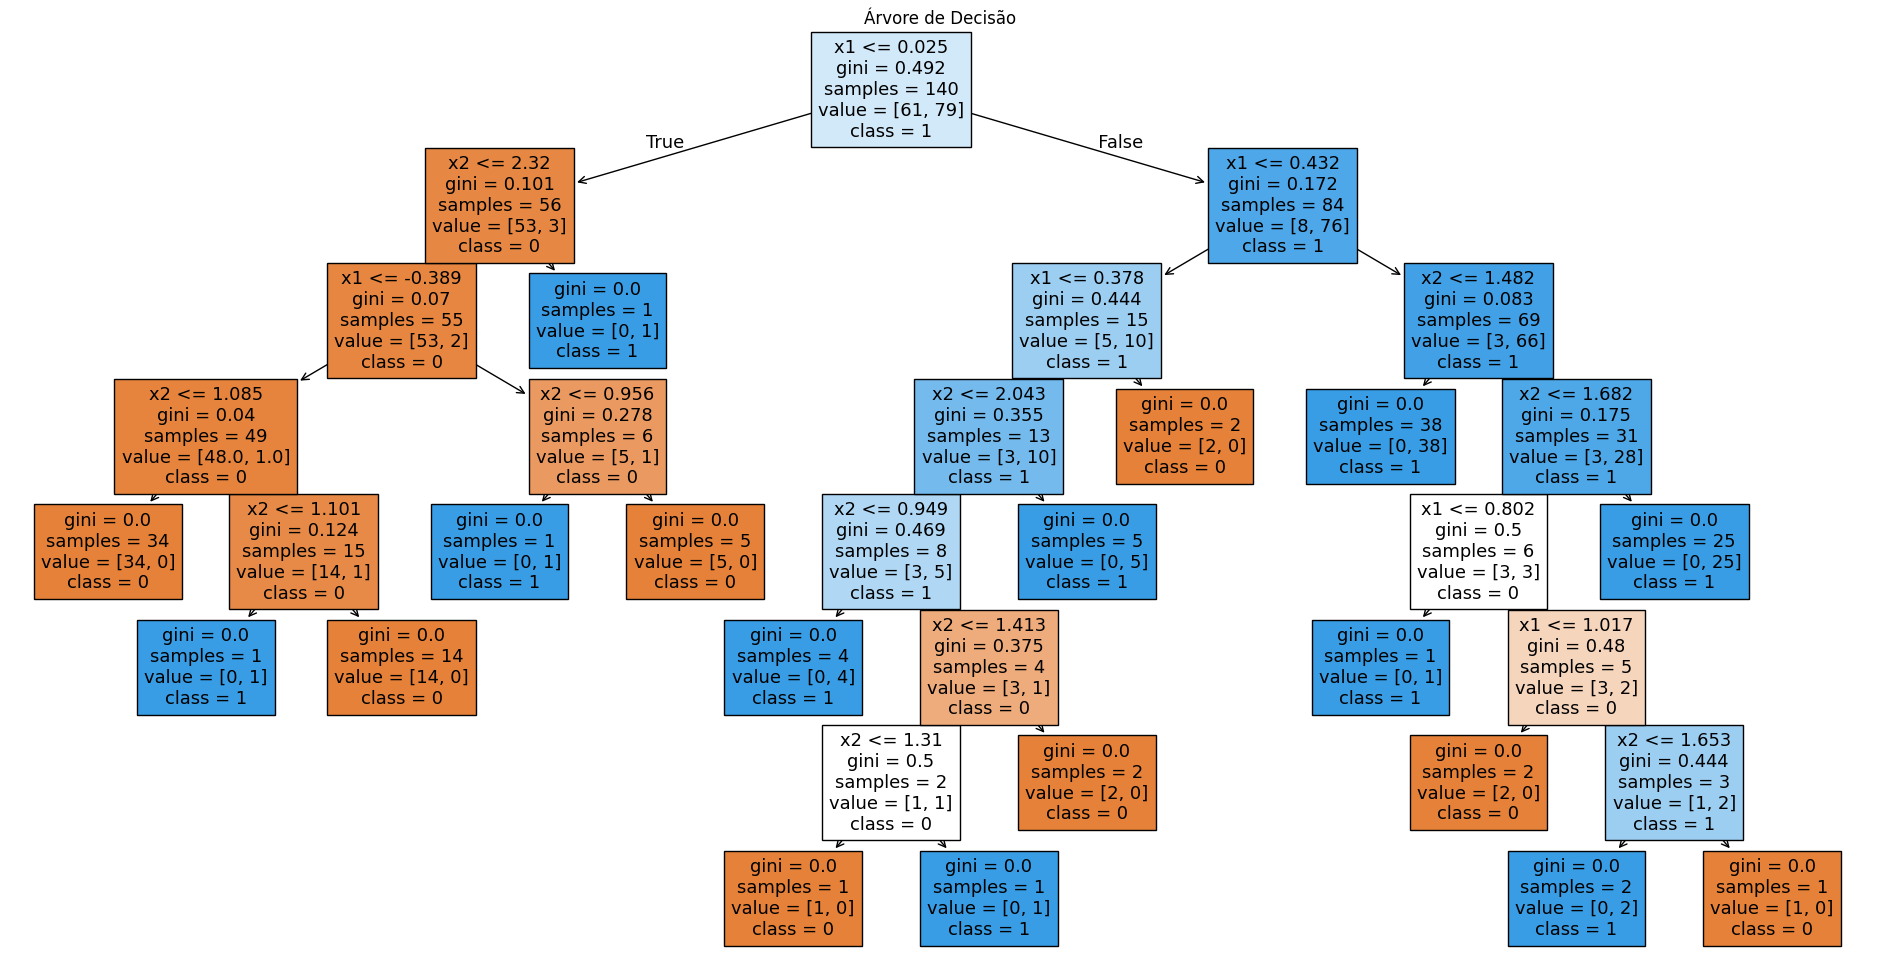

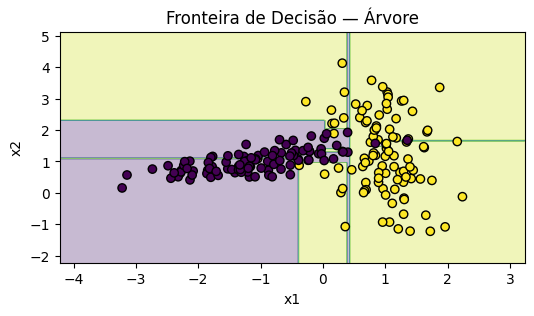

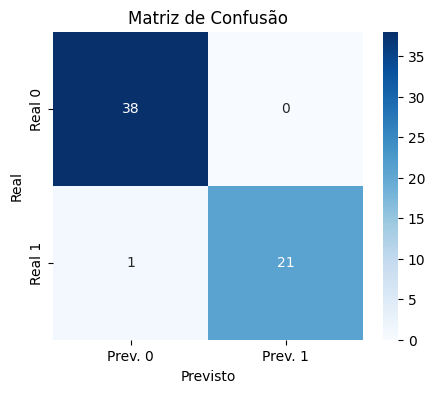

MÉTRICAS DO MODELO
Accuracy : 0.983
Precisão : 1.000
Recall   : 0.955
F1-score : 0.977


In [16]:
#Geração dos dados sintéticos e divisão em treino e teste
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

#MAX_DEPTH = none
model = DecisionTreeClassifier(max_depth=None)
model.fit(X_train, y_train)

#plotando a árvore de decisão
plt.figure(figsize=(24,12))
plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
plt.title("Árvore de Decisão")
plt.show()

# criando o meshgrid para poder plotar a imagem de superficie
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

#fazendo predições para todos os valores do meshgrd para plotar a fronteira
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plotando a fronteira de decisao
plt.figure(figsize=(6,3))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

plt.title("Fronteira de Decisão — Árvore")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

#plotando a matriz de confusao para identificar verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev. 0", "Prev. 1"],
            yticklabels=["Real 0", "Real 1"])

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# calculando e printando as 4 métricas de avaliação, que ajudam a analisar a matriz de confusão numéricamente
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DO MODELO")
print(f"Accuracy : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

quando max_depth=None as camadas vão sendo expandidas até que todos os nós finais (folhas) estejam puros (gini=0)

**Pergunta final:** Percebe-se portanto, que a profundidade da árvore de decisão impacta diretamente no desempenho da classificação. Se a profundidade for muito baixa, o modelo subajusta (underfitting) porque não tem complexidade suficiente para aprender os padrões dos dados. Por outro lado, se a profundidade é muito alta, o modelo pode sobreajustar (overfitting) porque memoriza os padrões dos dados de treinamento e não consegue generalizar para dados nunca vistos antes.

Em relação às métricas, quando o modelo subajusta, o desempenho é baixo tanto no conjunto de treinamento quanto no conjunto de teste, pois o modelo não consegue aprender com os dados. Já quando o modelo sobreajusta, o desempenho é alto no conjunto de treinamento e baixo no conjunto de teste, visto que o modelo não consegue generalizar.

### 2.

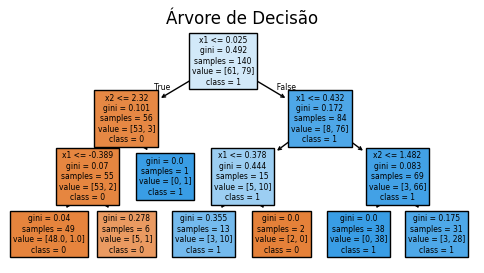

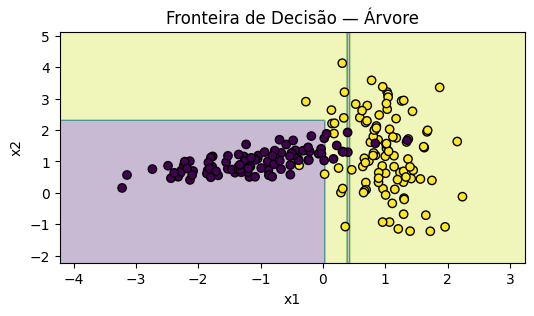

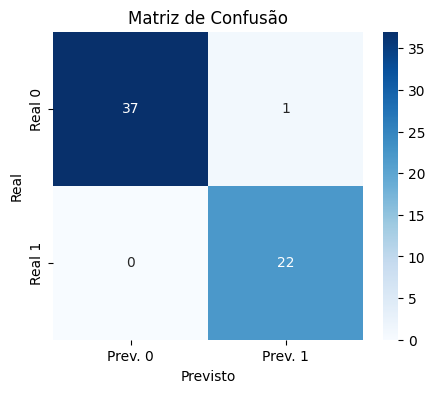

MÉTRICAS DO MODELO
Accuracy : 0.983
Precisão : 0.957
Recall   : 1.000
F1-score : 0.978


In [24]:
# Geração dos dados sintéticos e divisão em treino e teste
# dados originais
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

#MAX_DEPTH = 3 (mantendo a profundidade do exemplo original)
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

#plotando a árvore de decisão
plt.figure(figsize=(6,3))
plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
plt.title("Árvore de Decisão")
plt.show()

# criando o meshgrid para poder plotar a imagem de superficie
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

#fazendo predições para todos os valores do meshgrd para plotar a fronteira
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plotando a fronteira de decisao
plt.figure(figsize=(6,3))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

plt.title("Fronteira de Decisão — Árvore")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

#plotando a matriz de confusao para identificar verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev. 0", "Prev. 1"],
            yticklabels=["Real 0", "Real 1"])

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# calculando e printando as 4 métricas de avaliação, que ajudam a analisar a matriz de confusão numéricamente
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DO MODELO")
print(f"Accuracy : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

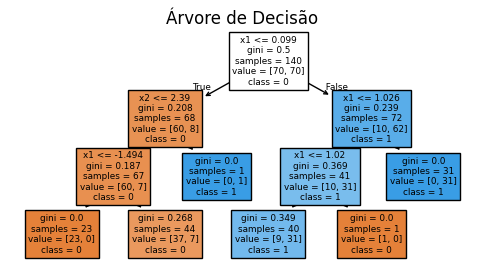

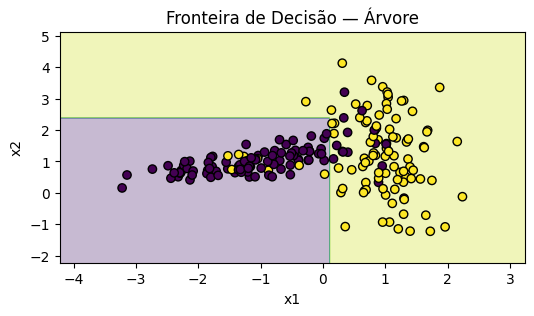

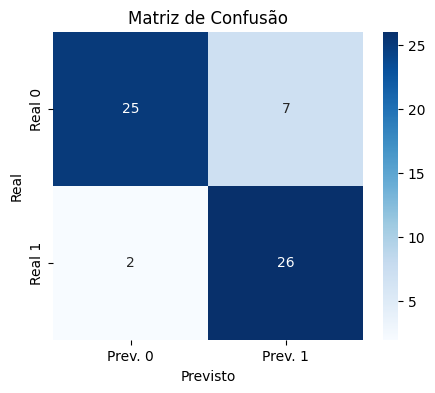

MÉTRICAS DO MODELO
Accuracy : 0.850
Precisão : 0.788
Recall   : 0.929
F1-score : 0.852


In [18]:
# Geração dos dados sintéticos e divisão em treino e teste
# Aumentando o ruído dos rótulos
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=0,flip_y=0.15)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

#MAX_DEPTH = 3 (mantendo a profundidade do exemplo original)
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

#plotando a árvore de decisão
plt.figure(figsize=(6,3))
plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
plt.title("Árvore de Decisão")
plt.show()

# criando o meshgrid para poder plotar a imagem de superficie
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

#fazendo predições para todos os valores do meshgrd para plotar a fronteira
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plotando a fronteira de decisao
plt.figure(figsize=(6,3))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

plt.title("Fronteira de Decisão — Árvore")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

#plotando a matriz de confusao para identificar verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev. 0", "Prev. 1"],
            yticklabels=["Real 0", "Real 1"])

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# calculando e printando as 4 métricas de avaliação, que ajudam a analisar a matriz de confusão numéricamente
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DO MODELO")
print(f"Accuracy : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

percebe-se que o desempenho do modelo caiu (número de falsos positivos e falsos negativos aumentou consideravelmente) devido ao ruído adicionado aos rótulos

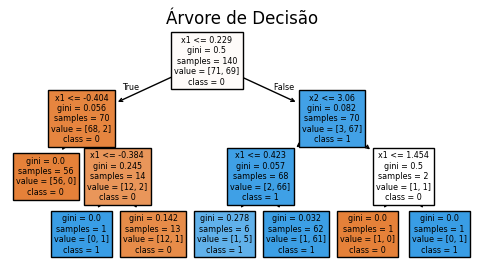

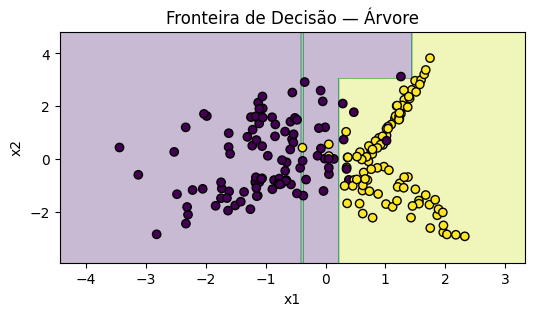

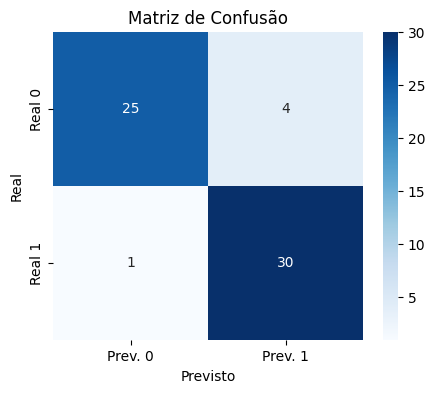

MÉTRICAS DO MODELO
Accuracy : 0.917
Precisão : 0.882
Recall   : 0.968
F1-score : 0.923


In [19]:
# Geração dos dados sintéticos e divisão em treino e teste
# Aumentando numero de clusters por classe para 2
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=2, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

#MAX_DEPTH = 3 (mantendo a profundidade do exemplo original)
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

#plotando a árvore de decisão
plt.figure(figsize=(6,3))
plot_tree(model, filled=True, feature_names=["x1", "x2"], class_names=["0","1"])
plt.title("Árvore de Decisão")
plt.show()

# criando o meshgrid para poder plotar a imagem de superficie
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

#fazendo predições para todos os valores do meshgrd para plotar a fronteira
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#plotando a fronteira de decisao
plt.figure(figsize=(6,3))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

plt.title("Fronteira de Decisão — Árvore")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

#plotando a matriz de confusao para identificar verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev. 0", "Prev. 1"],
            yticklabels=["Real 0", "Real 1"])

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# calculando e printando as 4 métricas de avaliação, que ajudam a analisar a matriz de confusão numéricamente
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DO MODELO")
print(f"Accuracy : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

O desempenho caiu um pouco, mas o modelo ainda consegue identificar o comportamento geral dos dois clusters. O modelo com essa complexidade não consegue identificar todas as amostras que estão "desconectadas" dos clusters

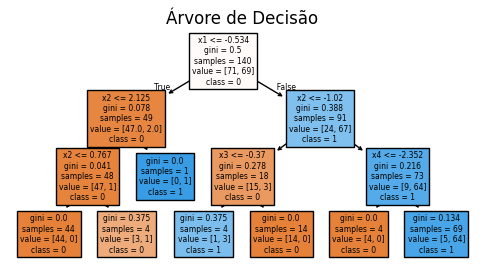

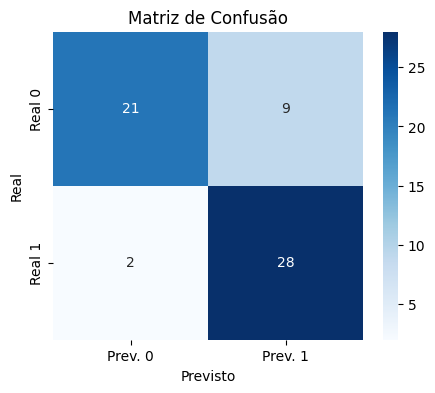

MÉTRICAS DO MODELO
Accuracy : 0.817
Precisão : 0.757
Recall   : 0.933
F1-score : 0.836


In [23]:
# Geração dos dados sintéticos e divisão em treino e teste
# Aumentando numero de features informativas para 4
X, y = make_classification(n_samples=200, n_features=4,
                           n_redundant=0, n_informative=4,
                           n_clusters_per_class=1, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

#MAX_DEPTH = 3 (mantendo a profundidade do exemplo original)
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

#plotando a árvore de decisão
plt.figure(figsize=(6,3))
plot_tree(model, filled=True, feature_names=["x1", "x2","x3","x4"], class_names=["0","1",'2','3'])
plt.title("Árvore de Decisão")
plt.show()

#não será plotada a superfície devido a dimensionalidade do problema
#os dados gerados continuam divididos em duas classes, por default n_classes=2
#mas n_features gera um espaço em 4D, não sendo possível plotar um gráfico sem realizar técnicas de redução de dimensionalidade

#plotando a matriz de confusao para identificar verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prev. 0", "Prev. 1"],
            yticklabels=["Real 0", "Real 1"])

plt.title("Matriz de Confusão")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# calculando e printando as 4 métricas de avaliação, que ajudam a analisar a matriz de confusão numéricamente
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MÉTRICAS DO MODELO")
print(f"Accuracy : {acc:.3f}")
print(f"Precisão : {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

Ao aumentar o número de atributos o desempenho do modelo também diminui. Já que a classificação se torna uma tarefa mais complexa, seria necessário aumentar a profundidade do modelo para manter o desempenho

**Pergunta final:** o modelo piorou mais quando adicionamos ruido aos rótulos e quando aumentamos a dimensionalidade do problema. Essas duas mudanças foram extremamente significativas para a classificação, pois o modelo teve mais dificuldade em identificar os dados. Em relação ao aumento de número de clusters de 1 para 2, a piora do desempenho foi um pouco mais atenuada, pois a profundidade de 3 camadas ainda conseguiu identificar o padrão. Possivelmente, caso o número de clusters aumentasse ainda mais o desempenho cairia significativamente, pois os dados ficariam ainda mais misturados.